In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Load scale data

In [21]:
data = pd.read_csv("Xtrain.csv", header=0).values.astype(float)  # (1000, 1)

scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler.fit_transform(data)          # keep scaler to invert later

# Window

In [22]:
LOOK_BACK = 30   # <-- TUNE THIS (try 10, 20, 30, 50)

def make_sequences(series, look_back):
    X, y = [], []
    for i in range(len(series) - look_back):
        X.append(series[i : i + look_back])
        y.append(series[i + look_back])
    return np.array(X), np.array(y)

X, y = make_sequences(data_scaled, LOOK_BACK)
# X shape: (N, look_back, 1)  — LSTM expects (batch, seq, features)
X = X.reshape(X.shape[0], LOOK_BACK, 1)

# Train/val split (80/20, no shuffling — time series!)
split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_val_t   = torch.FloatTensor(X_val)
y_val_t   = torch.FloatTensor(y_val)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=32, shuffle=False)

# LSTM Model

In [23]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])   # only last timestep

model = LSTMForecaster(hidden_size=64, num_layers=2, dropout=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

# Train + ES

In [24]:
EPOCHS = 200
PATIENCE = 30   # number of epochs to wait
counter = 0
best_val_loss = float('inf')
best_state = None

for epoch in range(EPOCHS):
    model.train()
    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, y_val_t).item()

    scheduler.step(val_loss)

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict().copy()
        counter = 0   # reset
    else:
        counter += 1

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | val_loss: {val_loss:.6f}")

    if counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

# Restore best model
model.load_state_dict(best_state)

Epoch   0 | val_loss: 0.126723
Epoch  20 | val_loss: 0.009834
Epoch  40 | val_loss: 0.003452
Epoch  60 | val_loss: 0.001309
Epoch  80 | val_loss: 0.000945
Epoch 100 | val_loss: 0.000715
Epoch 120 | val_loss: 0.000682
Early stopping at epoch 132


<All keys matched successfully>

In [25]:
model.eval()
with torch.no_grad():
    val_pred = model(X_val_t).numpy()

# Inverse scale
val_pred_inv = scaler.inverse_transform(val_pred)
y_val_inv = scaler.inverse_transform(y_val)

mae_val = mean_absolute_error(y_val_inv, val_pred_inv)
mse_val = mean_squared_error(y_val_inv, val_pred_inv)

print(f"Validation MAE: {mae_val:.4f}")
print(f"Validation MSE: {mse_val:.4f}")
print(f"Accuracy: {(1 - mae_val / np.mean(np.abs(y_val_inv))) * 100:.2f}%")

Validation MAE: 2.4934
Validation MSE: 10.9171
Accuracy: 95.93%


# Predict 200

In [26]:
model.eval()
# Seed the window with the last LOOK_BACK points of training data
window = data_scaled[-LOOK_BACK:].reshape(1, LOOK_BACK, 1).tolist()
window = list(np.array(window).flatten())

predictions_scaled = []
with torch.no_grad():
    for _ in range(200):
        inp = torch.FloatTensor(window[-LOOK_BACK:]).reshape(1, LOOK_BACK, 1)
        pred = model(inp).item()
        predictions_scaled.append(pred)
        window.append(pred)

# Invert scaling
predictions = scaler.inverse_transform(
    np.array(predictions_scaled).reshape(-1, 1)
).flatten()

print("Predicted range:", predictions.min(), "–", predictions.max())
print("Training data range:", data.min(), "–", data.max())

Predicted range: 11.150008648633946 – 174.17725597321987
Training data range: 2.0 – 255.0


# Plot

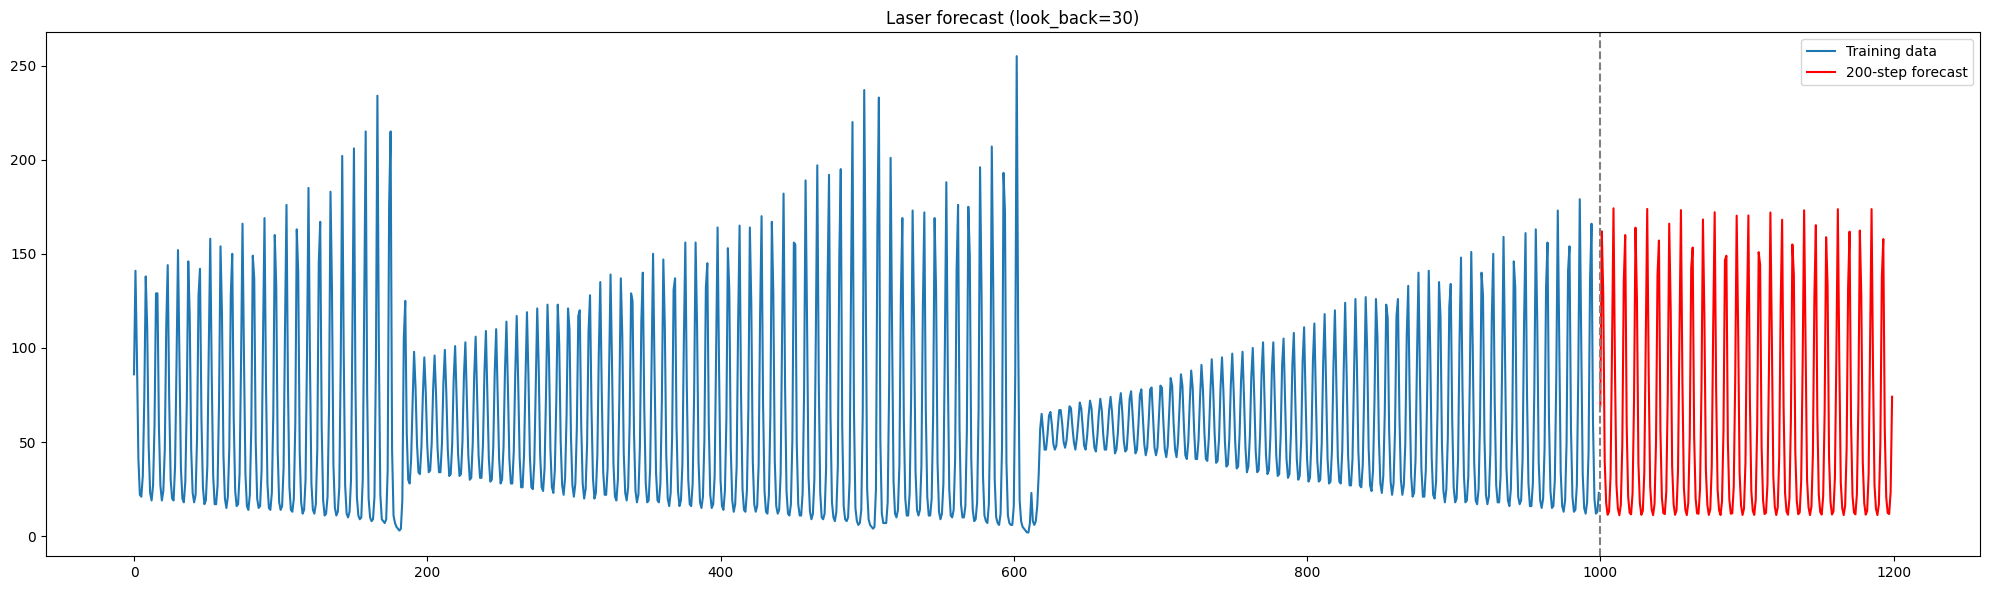

In [27]:
plt.figure(figsize=(20, 6))
plt.plot(range(1000), data.flatten(), label="Training data")
plt.plot(range(1000, 1200), predictions, label="200-step forecast", color="red")
plt.axvline(1000, linestyle='--', color='gray')
plt.legend()
plt.title(f"Laser forecast (look_back={LOOK_BACK})")
plt.tight_layout()
plt.savefig("forecast.png", dpi=150)
plt.show()

# Evaluate on test set (run after May 8th)

In [28]:
#Xtest = pd.read_csv("Xtest.csv", header=0).values.astype(float).flatten()

In [29]:
# Xtest = pd.read_csv("Xtest.csv", header=0).values.astype(float).flatten()
# mae = mean_absolute_error(Xtest, predictions)
# mse = mean_squared_error(Xtest, predictions)
# print(f"MAE: {mae:.4f} | MSE: {mse:.4f}")

In [30]:
# plt.figure(figsize=(12, 4))
# plt.plot(Xtest, label="Real test data")
# plt.plot(predictions, label="Predictions", color="red")
# plt.legend()
# plt.title("Prediction vs Real Test Data")
# plt.tight_layout()
# plt.show()

# Hyperparam randomsearch

In [31]:
param_grid = {
    "look_back": [10, 30, 50, 100],
    "hidden_size": [32, 64],
    "num_layers": [1, 2, 3],
    "dropout": [0.0, 0.2],
    "lr": [1e-3, 5e-4]
}

In [32]:
import random

def sample_params():
    return {
        "look_back": random.choice([10, 30, 50, 100]),
        "hidden_size": random.choice([32, 64]),
        "num_layers": random.choice([1, 2, 3]),
        "dropout": random.choice([0.0, 0.2]),
        "lr": random.choice([1e-3, 5e-4])
    }

In [ ]:
def train_model(params):
    LOOK_BACK = params["look_back"]

    X, y = make_sequences(data_scaled, LOOK_BACK)
    X = X.reshape(X.shape[0], LOOK_BACK, 1)

    split = int(0.8 * len(X))
    X_train, X_val = X[:split], X[split:]
    y_train, y_val = y[:split], y[split:]

    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train)
    X_val_t   = torch.FloatTensor(X_val)
    y_val_t   = torch.FloatTensor(y_val)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                              batch_size=32, shuffle=False)
    
    dropout = params["dropout"] if params["num_layers"] > 1 else 0.0

    model = LSTMForecaster(
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"],
        dropout=dropout
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])
    criterion = nn.MSELoss()

    best_val = float('inf')

    for epoch in range(150):   # keep it shorter for tuning
        model.train()
        for xb, yb in train_loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()

        best_val = min(best_val, val_loss)

    return best_val

In [34]:
N_TRIALS = 20

results = []

for i in range(N_TRIALS):
    params = sample_params()
    val_loss = train_model(params)

    results.append((params, val_loss))
    print(f"Trial {i}: {params} → {val_loss:.6f}")

best = min(results, key=lambda x: x[1])
print("\nBest config:", best[0])
print("Best val loss:", best[1])

Trial 0: {'look_back': 30, 'hidden_size': 64, 'num_layers': 3, 'dropout': 0.2, 'lr': 0.001} → 0.000221


KeyboardInterrupt: 